In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
!pip install numpy 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [5]:
df.head(20)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape[0]

2640

In [9]:
df.shape[1]

12

In [10]:
df.dtypes

Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

In [13]:
df[['Model', 'Region', 'Source_Type']].nunique()

Model          5
Region         4
Source_Type    3
dtype: int64

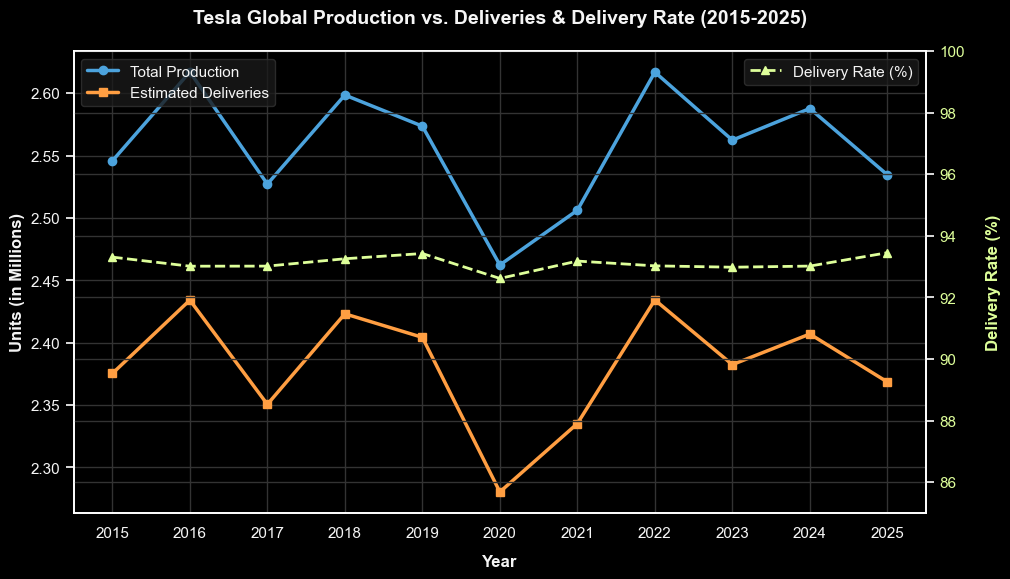

In [ ]:
yearly_data = df.groupby('Year')[['Production_Units', 'Estimated_Deliveries']].sum().reset_index()

yearly_data['Delivery_Rate_%'] = (yearly_data['Estimated_Deliveries'] / yearly_data['Production_Units']) * 100

custom_dark_params = {
    "axes.facecolor": "#000000",       
    "figure.facecolor": "#000000",     
    "text.color": "#f5f5f5",           
    "axes.labelcolor": "#f5f5f5",      
    "xtick.color": "#f5f5f5",          
    "ytick.color": "#f5f5f5",          
    "grid.color": "#333333"            
}
sns.set_theme(style="darkgrid", rc=custom_dark_params)

fig, ax1 = plt.subplots(figsize=(11, 6))


color_prod = '#4ca3dd'  
color_deliv = '#ff9e42' 
color_rate = '#deff9a'  


ax1.plot(yearly_data['Year'], yearly_data['Production_Units'] / 1e6, 
         marker='o', color=color_prod, linewidth=2.5, label='Total Production')
ax1.plot(yearly_data['Year'], yearly_data['Estimated_Deliveries'] / 1e6, 
         marker='s', color=color_deliv, linewidth=2.5, label='Estimated Deliveries')


ax1.set_xlabel('Year', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Units (in Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Tesla Global Production vs. Deliveries & Delivery Rate (2015-2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(yearly_data['Year'])
ax1.tick_params(axis='y')


ax1.legend(loc='upper left', frameon=True, facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#f5f5f5')


ax2 = ax1.twinx()
ax2.plot(yearly_data['Year'], yearly_data['Delivery_Rate_%'], 
         marker='^', color=color_rate, linestyle='--', linewidth=2, label='Delivery Rate (%)')


ax2.set_ylabel('Delivery Rate (%)', fontsize=12, color=color_rate, fontweight='bold', labelpad=15)
ax2.tick_params(axis='y', labelcolor=color_rate)
ax2.set_ylim(85, 100)  


ax2.legend(loc='upper right', frameon=True, facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#f5f5f5')


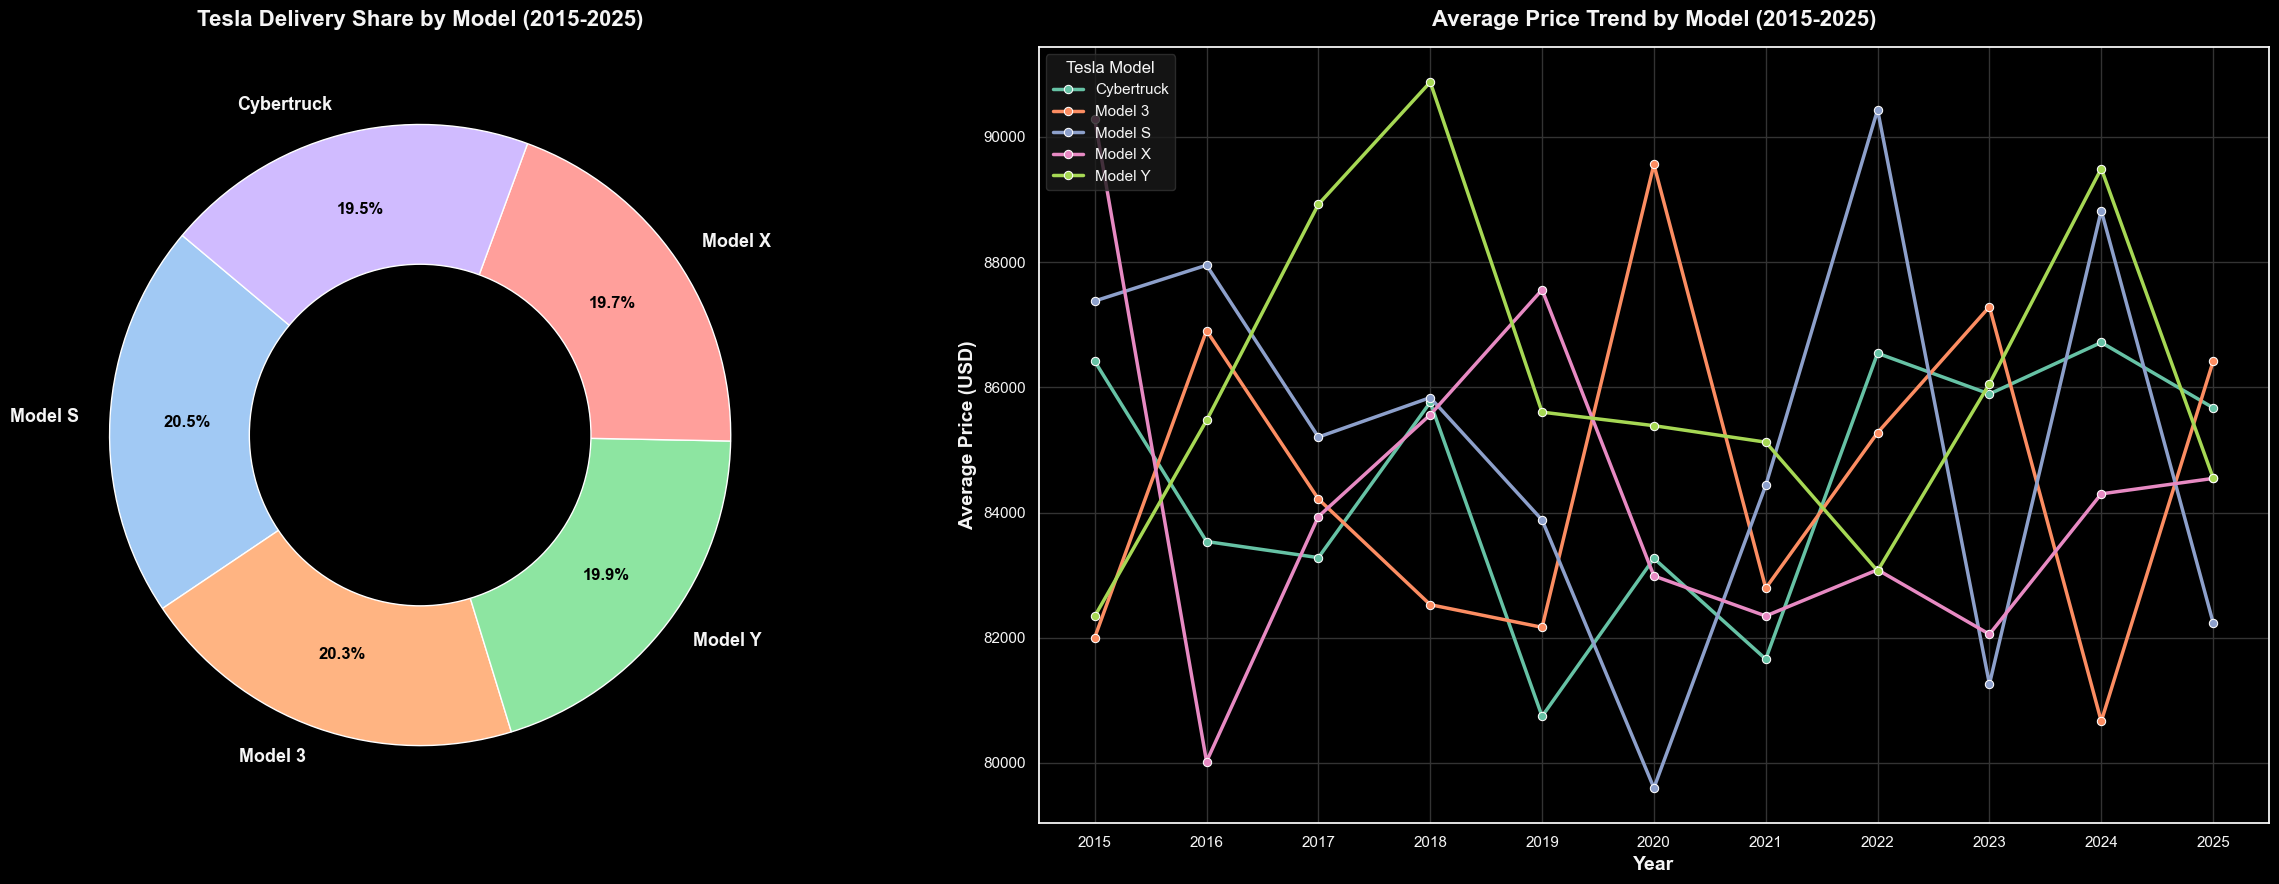

In [14]:
# 2. 數據聚合處理
# 計算車型總銷量，並從大到小排序
model_share = df.groupby('Model')['Estimated_Deliveries'].sum().reset_index()
model_share = model_share.sort_values(by='Estimated_Deliveries', ascending=False)

# 計算各車型歷年的平均售價
price_trend = df.groupby(['Year', 'Model'])['Avg_Price_USD'].mean().reset_index()

# 3. 設定視覺化風格 (改為黑色深色主題)
custom_dark_params = {
    "axes.facecolor": "#000000",       # 座標軸內背景改為黑色
    "figure.facecolor": "#000000",     # 畫布外背景改為黑色
    "text.color": "#f5f5f5",           # 標題等一般文字改為米白色
    "axes.labelcolor": "#f5f5f5",      # X, Y 軸標籤改為米白色
    "xtick.color": "#f5f5f5",          # X 軸刻度文字改為米白色
    "ytick.color": "#f5f5f5",          # Y 軸刻度文字改為米白色
    "grid.color": "#333333"            # 網格線改為深灰色
}
sns.set_theme(style="darkgrid", rc=custom_dark_params)

# 建立 1 列 2 欄的並排畫布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 9))

# --- [左圖] 繪製車型銷量市佔率（環狀圖） ---
colors = sns.color_palette('pastel')[0:5]

# 繪製圓餅圖，透過 textprops 將圖外圍的車型標籤改成米白色
wedges, texts, autotexts = ax1.pie(model_share['Estimated_Deliveries'], 
                                  labels=model_share['Model'], 
                                  autopct='%1.1f%%', 
                                  startangle=140, 
                                  colors=colors,
                                  pctdistance=0.75,
                                  textprops={'color': '#f5f5f5'}) 

# 在圓心畫一個【黑色】的圓圈，將圓餅圖轉化為環狀圖，完美融入黑底
centre_circle = plt.Circle((0,0), 0.55, fc='#000000')
ax1.add_artist(centre_circle)

# 優化文字標籤的可讀性
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    # 因為 pastel 顏色比較明亮，裡面的百分比文字設定為黑色會更清楚！
    autotext.set_color('#000000') 

ax1.set_title('Tesla Delivery Share by Model (2015-2025)', fontsize=16, fontweight='bold', pad=15)

# --- [右圖] 繪製歷年車型售價走勢（多線折線圖） ---
sns.lineplot(data=price_trend, x='Year', y='Avg_Price_USD', hue='Model', 
             marker='o', linewidth=2.5, ax=ax2, palette='Set2')

ax2.set_title('Average Price Trend by Model (2015-2025)', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Price (USD)', fontsize=14, fontweight='bold')
ax2.set_xticks(price_trend['Year'].unique())

# 將圖例 (Legend) 改成黑底白字，確保完美融入背景
legend = ax2.legend(title='Tesla Model', loc='upper left', frameon=True, 
                    facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#f5f5f5')
# 確保圖例的標題 ("Tesla Model") 也是淺色的
plt.setp(legend.get_title(), color='#f5f5f5')

# 4. 自動調整布局，並高畫質存檔 (確保儲存時 facecolor 為黑底)
plt.tight_layout()

C:\Users\USER\AppData\Local\Temp\ipykernel_14948\2588598095.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_deliv, x='Region', y='Estimated_Deliveries', palette='Blues_r', ax=ax1)
C:\Users\USER\AppData\Local\Temp\ipykernel_14948\2588598095.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax1.get_yticks()])
C:\Users\USER\AppData\Local\Temp\ipykernel_14948\2588598095.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_charge, x='Region', y='Charging_Stations', palette='Greens_r', ax=ax2)
C:\Users\USER\AppData\Local\Temp\i

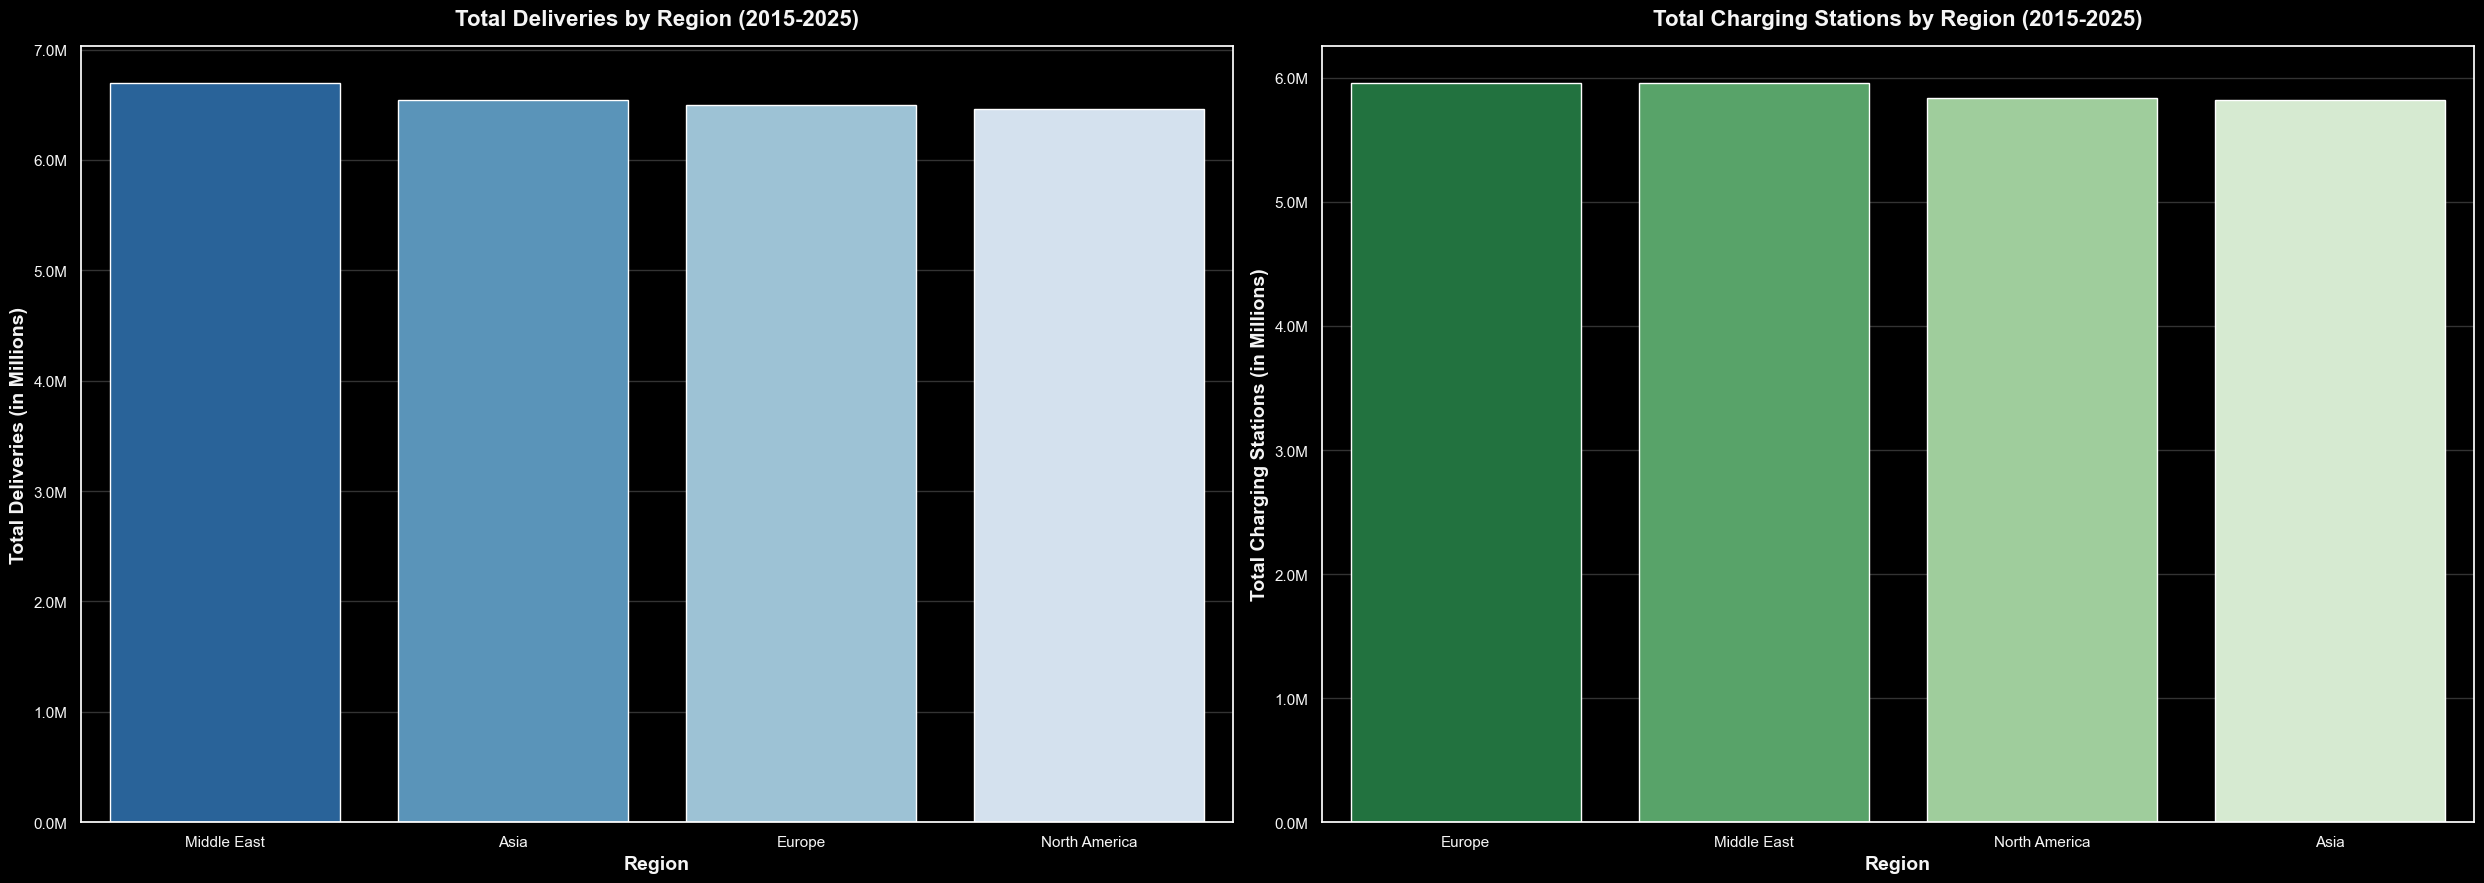

In [15]:
# 2. 數據聚合處理（按區域加總交車量與充電站）
region_data = df.groupby('Region')[['Estimated_Deliveries', 'Charging_Stations']].sum().reset_index()

# 3. 設定視覺化風格 (改為黑色深色主題)
custom_dark_params = {
    "axes.facecolor": "#000000",       # 座標軸內背景改為黑色
    "figure.facecolor": "#000000",     # 畫布外背景改為黑色
    "text.color": "#f5f5f5",           # 標題等一般文字改為米白色
    "axes.labelcolor": "#f5f5f5",      # X, Y 軸標籤改為米白色
    "xtick.color": "#f5f5f5",          # X 軸刻度文字改為米白色
    "ytick.color": "#f5f5f5",          # Y 軸刻度文字改為米白色
    "grid.color": "#333333"            # 網格線改為深灰色
}
sns.set_theme(style="darkgrid", rc=custom_dark_params)

# 建立 1 列 2 欄的並排畫布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 9))

# --- [左圖] 繪製區域總交車量（依销銷量由大到小排序） ---
region_deliv = region_data.sort_values(by='Estimated_Deliveries', ascending=False)
# 備註：在黑底上，Blues_r 或明亮的漸層色會看起來非常有科技感
sns.barplot(data=region_deliv, x='Region', y='Estimated_Deliveries', palette='Blues_r', ax=ax1)

# 字體稍微放大 (14 -> 16, 12 -> 14) 讓簡報投影更清楚
ax1.set_title('Total Deliveries by Region (2015-2025)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Region', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Deliveries (in Millions)', fontsize=14, fontweight='bold')

# 將 Y 軸標籤格式化為百萬 (M)
# 注意：舊版 Matplotlib 需要先設定 tick 位置，為了避免警告，建議改用 FuncFormatter，或保持原樣若無錯誤
ax1.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax1.get_yticks()])

# --- [右圖] 繪製區域總充電站數量（依充電站數量由大到小排序） ---
region_charge = region_data.sort_values(by='Charging_Stations', ascending=False)
sns.barplot(data=region_charge, x='Region', y='Charging_Stations', palette='Greens_r', ax=ax2)

ax2.set_title('Total Charging Stations by Region (2015-2025)', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Region', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Charging Stations (in Millions)', fontsize=14, fontweight='bold')
# 將 Y 軸標籤格式化為百萬 (M)
ax2.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax2.get_yticks()])

# 4. 自動調整布局並高畫質存檔 (確保儲存時 facecolor 為黑底)
plt.tight_layout()

C:\Users\USER\AppData\Local\Temp\ipykernel_14948\1922648999.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='Set2', ax=ax2)


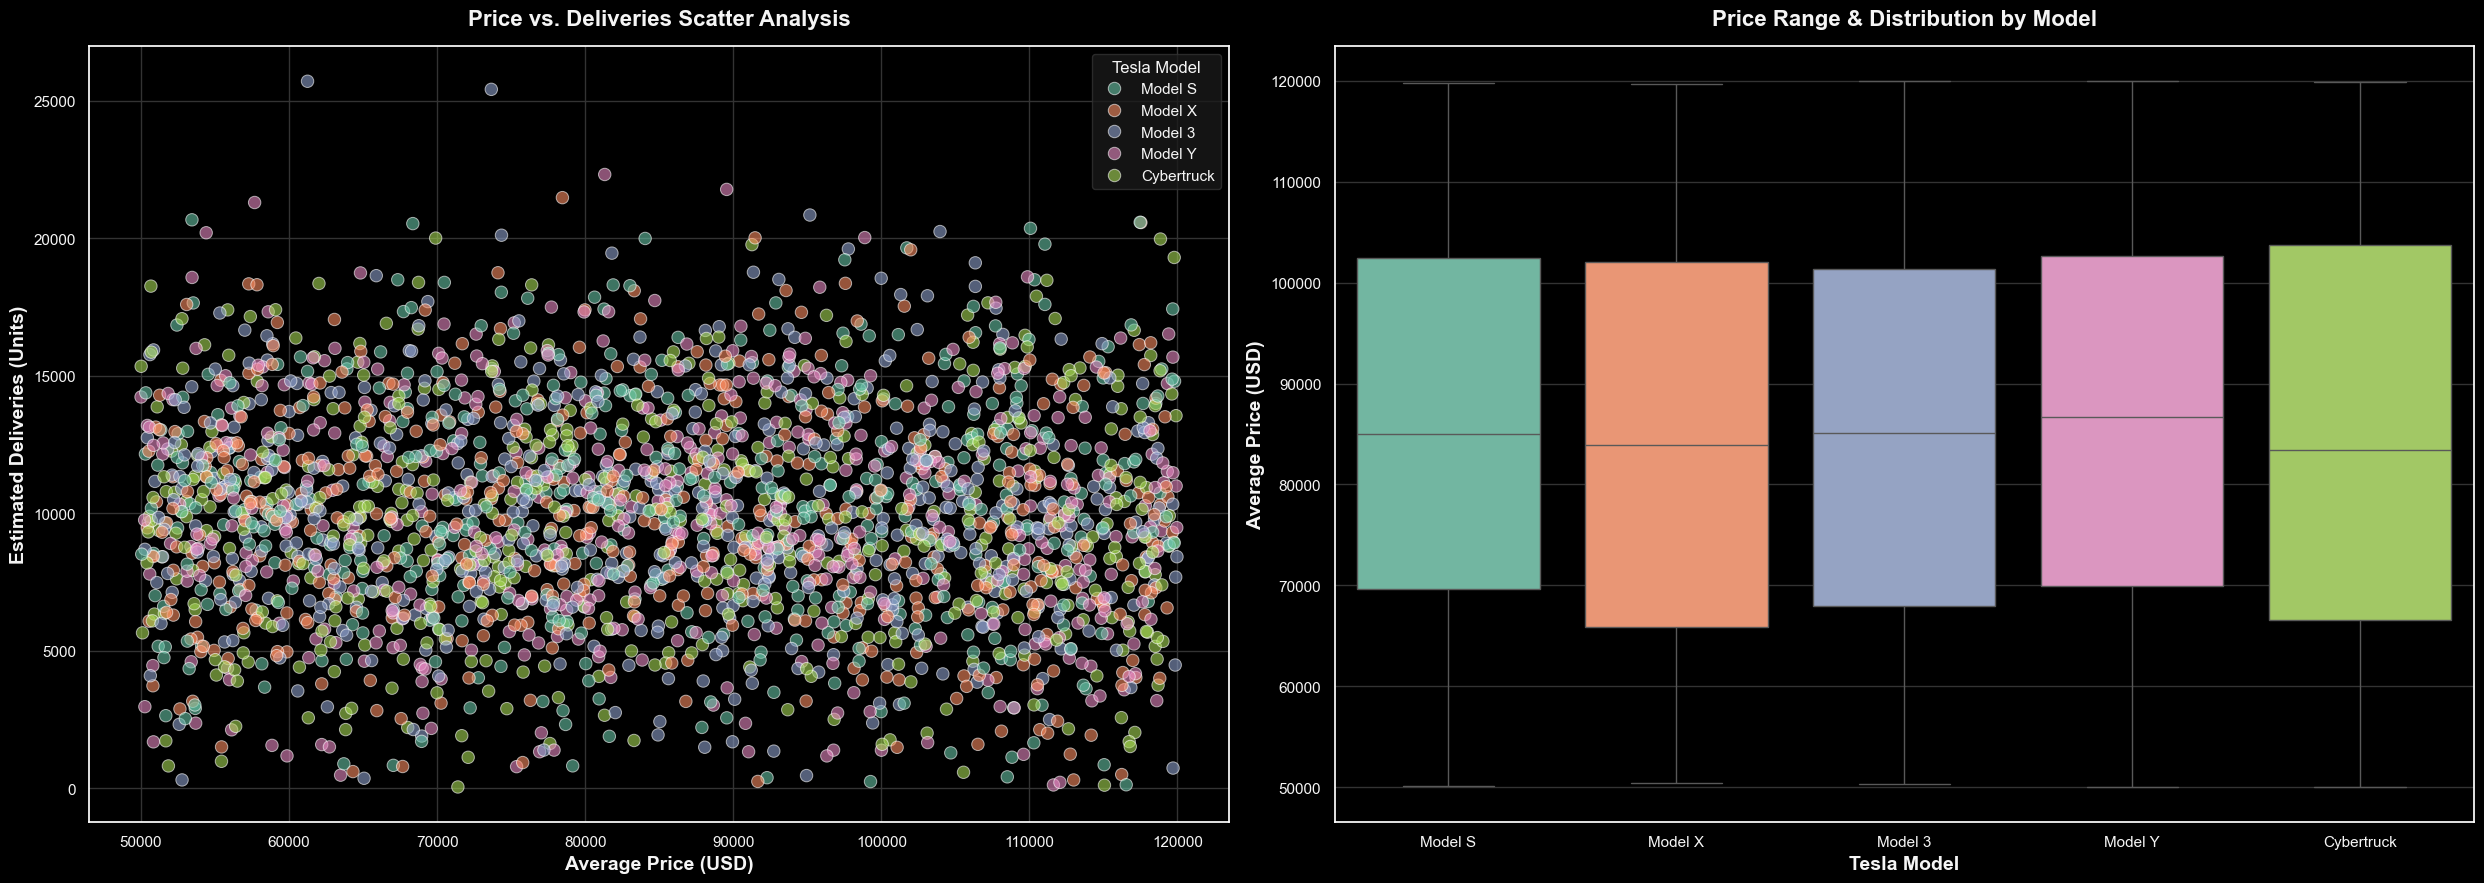

In [16]:
# 2. 設定視覺化風格 (改為黑色深色主題)
custom_dark_params = {
    "axes.facecolor": "#000000",       # 座標軸內背景改為黑色
    "figure.facecolor": "#000000",     # 畫布外背景改為黑色
    "text.color": "#f5f5f5",           # 標題等一般文字改為米白色
    "axes.labelcolor": "#f5f5f5",      # X, Y 軸標籤改為米白色
    "xtick.color": "#f5f5f5",          # X 軸刻度文字改為米白色
    "ytick.color": "#f5f5f5",          # Y 軸刻度文字改為米白色
    "grid.color": "#333333"            # 網格線改為深灰色
}
sns.set_theme(style="darkgrid", rc=custom_dark_params)

# 建立 1 列 2 欄的並排畫布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 9))

# --- [左圖] 價格 vs 交付量散佈圖（分析需求彈性） ---
# 將 alpha 調為 0.6，並加上 s=80 放大點距，在黑底上呈現更佳的視覺密度
sns.scatterplot(data=df, x='Avg_Price_USD', y='Estimated_Deliveries', 
                hue='Model', alpha=0.6, s=80, palette='Set2', ax=ax1)

# 字體稍微放大 (14 -> 16, 12 -> 14) 讓簡報投影更清楚
ax1.set_title('Price vs. Deliveries Scatter Analysis', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Average Price (USD)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Estimated Deliveries (Units)', fontsize=14, fontweight='bold')

# 將圖例 (Legend) 改成黑底白字
legend1 = ax1.legend(title='Tesla Model', loc='upper right', frameon=True, 
                     facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#f5f5f5')
plt.setp(legend1.get_title(), color='#f5f5f5')

# --- [右圖] 車型售價箱線圖（分析定價分布） ---
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='Set2', ax=ax2)

# 字體稍微放大
ax2.set_title('Price Range & Distribution by Model', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Tesla Model', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Price (USD)', fontsize=14, fontweight='bold')

# 3. 自動調整布局並高畫質存檔 (確保儲存時 facecolor 為黑底)
plt.tight_layout()

C:\Users\USER\AppData\Local\Temp\ipykernel_14948\2711807136.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax2.get_yticks()])


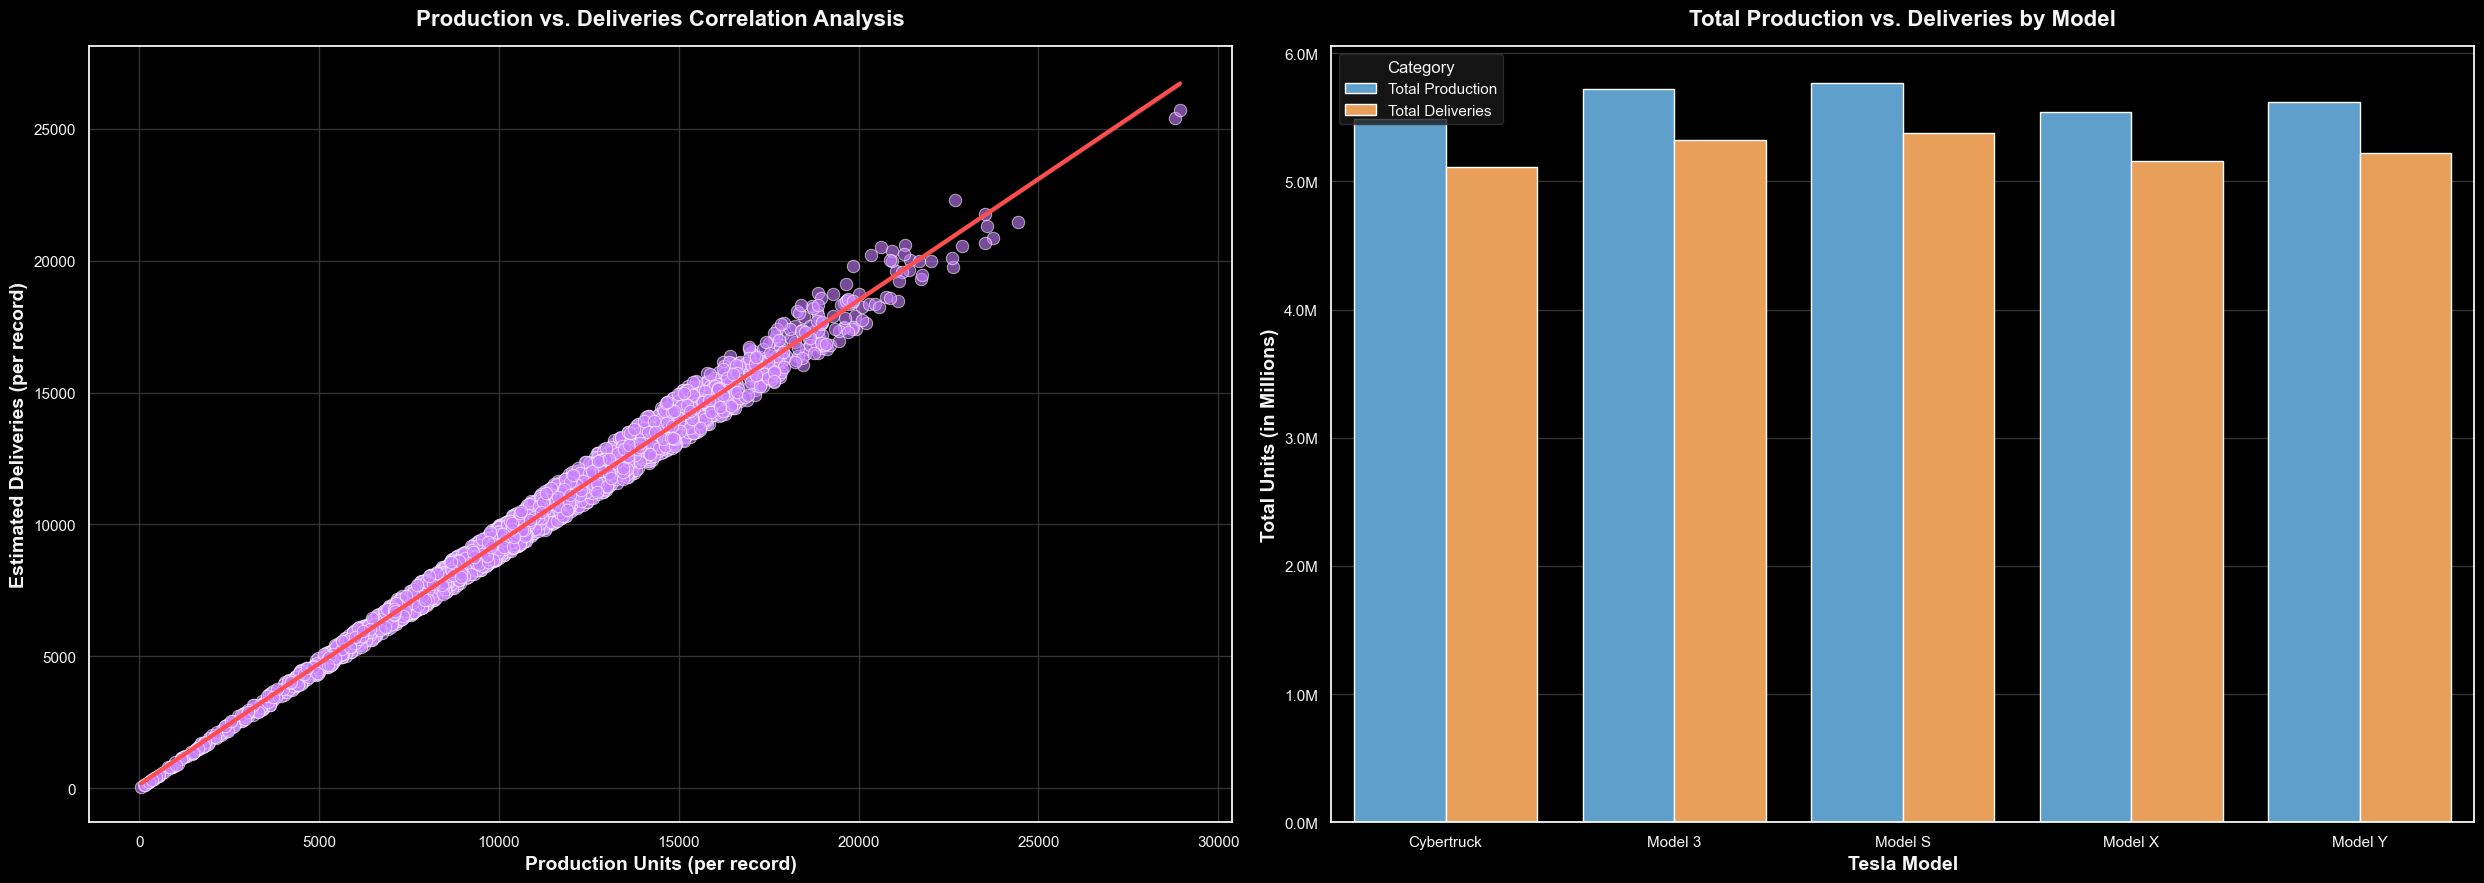

In [17]:
# 2. 數據處理：為右圖計算各車型的總產量與總交車量
model_data = df.groupby('Model')[['Production_Units', 'Estimated_Deliveries']].sum().reset_index()

# 使用 pd.melt 將資料轉為長格式，方便 Seaborn 繪製分組長條圖
model_melted = model_data.melt(id_vars='Model', 
                               value_vars=['Production_Units', 'Estimated_Deliveries'],
                               var_name='Category', value_name='Units')

# 將欄位名稱優化，讓圖例更好看
model_melted['Category'] = model_melted['Category'].map({
    'Production_Units': 'Total Production',
    'Estimated_Deliveries': 'Total Deliveries'
})

# 3. 設定視覺化風格 (改為黑色深色主題)
custom_dark_params = {
    "axes.facecolor": "#000000",       # 座標軸內背景改為黑色
    "figure.facecolor": "#000000",     # 畫布外背景改為黑色
    "text.color": "#f5f5f5",           # 標題等一般文字改為米白色
    "axes.labelcolor": "#f5f5f5",      # X, Y 軸標籤改為米白色
    "xtick.color": "#f5f5f5",          # X 軸刻度文字改為米白色
    "ytick.color": "#f5f5f5",          # Y 軸刻度文字改為米白色
    "grid.color": "#333333"            # 網格線改為深灰色
}
sns.set_theme(style="darkgrid", rc=custom_dark_params)

# 建立 1 列 2 欄的並排畫布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 9))

# --- [左圖] 微觀分析：生產與交付的相關性散佈圖 ---
# 將點放大 (s=80)，alpha 調為 0.6，並改用亮紫色讓黑底視覺更突出
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries', 
                alpha=0.6, s=80, color='#c77dff', ax=ax1)
# 迴歸線改為更亮的紅色
sns.regplot(data=df, x='Production_Units', y='Estimated_Deliveries', 
            scatter=False, color='#ff4d4d', ax=ax1, line_kws={"linewidth": 3})

# 字體稍微放大 (14 -> 16, 12 -> 14) 讓簡報投影更清楚
ax1.set_title('Production vs. Deliveries Correlation Analysis', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Production Units (per record)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Estimated Deliveries (per record)', fontsize=14, fontweight='bold')

# --- [右圖] 宏觀分析：各車型總產量 vs 總交車量對比 ---
# 使用自訂的亮藍與亮橘配色，呼應第一張圖表的色彩邏輯
custom_palette = {'Total Production': '#4ca3dd', 'Total Deliveries': '#ff9e42'}
sns.barplot(data=model_melted, x='Model', y='Units', hue='Category', palette=custom_palette, ax=ax2)

# 字體稍微放大
ax2.set_title('Total Production vs. Deliveries by Model', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Tesla Model', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Units (in Millions)', fontsize=14, fontweight='bold')

# 將 Y 軸標籤格式化為百萬 (M)
ax2.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax2.get_yticks()])

# 將圖例 (Legend) 改成黑底白字，確保完美融入背景
legend = ax2.legend(title='Category', loc='upper left', frameon=True, 
                    facecolor='#1a1a1a', edgecolor='#333333', labelcolor='#f5f5f5')
plt.setp(legend.get_title(), color='#f5f5f5')

# 4. 自動調整布局並高畫質存檔 (確保儲存時 facecolor 為黑底)
plt.tight_layout()